# Stocks 1
- https://pypi.org/project/ffn/
- https://pmorissette.github.io/ffn/quick.html
- https://pmorissette.github.io/ffn/ffn.html
- https://finance.yahoo.com/quotes/AAPL,MSFT,GE/
- https://finance.yahoo.com/lookup/  Ticker

In [1]:
#!pip install ffn

In [2]:
import ffn

In [3]:
returns = ffn.get('aapl,msft,c,gs,ge', start='2020-01-01').to_returns().dropna()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
returns.head()

,aapl,msft,c,gs,ge
Date,,,,,
2020-01-03,-0.009722,-0.012452,-0.018835,-0.011693,0.003353
2020-01-06,0.007968,0.002585,-0.003137,0.010234,0.014202
2020-01-07,-0.004703,-0.009118,-0.008685,0.006583,-0.007414
2020-01-08,0.016086,0.015928,0.007618,0.009639,-0.009129
2020-01-09,0.021241,0.012493,0.009073,0.020357,-0.002513


In [5]:
returns.calc_mean_var_weights().as_format('.2%')

aapl    27.49%
msft    15.32%
c        0.00%
gs      24.33%
ge      32.85%
dtype: object

In [6]:
data = ffn.get('agg,hyg,spy,eem,efa', start='2020-01-01', end='2025-12-30')
print(data.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

                  agg        hyg         spy        eem        efa
Date                                                              
2020-01-02  95.057961  64.169510  297.698975  40.087055  58.637096
2020-01-03  95.336342  64.104141  295.444733  39.342770  57.909760
2020-01-06  95.260445  64.038742  296.571899  39.246441  58.135487
2020-01-07  95.159164  63.980610  295.737976  39.220173  57.976646
2020-01-08  95.049530  64.038742  297.314148  39.447834  58.143848


- By default, the data is downloaded from Yahoo! Finance and the Adjusted Close is used as the security’s price. Other data sources are also available and you may select other fields as well. Fields are specified by using the following format: {ticker}:{field}. So, if we want to get the Open, High, Low, Close for aapl, we would do the following:
- data = ffn.get('dbc', provider=ffn.data.csv, path='test_data.csv', existing=data)
- print(data.head())

In [7]:
print(ffn.get('aapl:Open,aapl:High,aapl:Low,aapl:Close', start='2020-01-01', end='2025-12-30').head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

             aaplopen   aaplhigh    aapllow  aaplclose
Date                                                  
2020-01-02  74.059998  75.150002  73.797501  75.087502
2020-01-03  74.287498  75.144997  74.125000  74.357498
2020-01-06  73.447502  74.989998  73.187500  74.949997
2020-01-07  74.959999  75.224998  74.370003  74.597504
2020-01-08  74.290001  76.110001  74.290001  75.797501


## Manipulations

In [8]:
returns = data.to_log_returns().dropna()
print(returns.head())

                 agg       hyg       spy       eem       efa
Date                                                        
2020-01-03  0.002924 -0.001019 -0.007601 -0.018741 -0.012482
2020-01-06 -0.000796 -0.001021  0.003808 -0.002451  0.003890
2020-01-07 -0.001064 -0.000908 -0.002816 -0.000670 -0.002736
2020-01-08 -0.001153  0.000908  0.005315  0.005788  0.002880
2020-01-09  0.001064  0.002606  0.006758  0.006637  0.002298


In [9]:
returns.tail()

,agg,hyg,spy,eem,efa
Date,,,,,
2025-12-22,-0.000401,0.000871,0.006211,0.005384,0.002511
2025-12-23,0.000000,0.000746,0.004560,0.005539,0.006146
2025-12-24,0.002202,0.001862,0.003511,0.002023,0.001245
2025-12-26,0.000200,-0.000496,-0.000101,0.006958,0.001658
2025-12-29,0.001199,0.000372,-0.003570,-0.002558,-0.003008


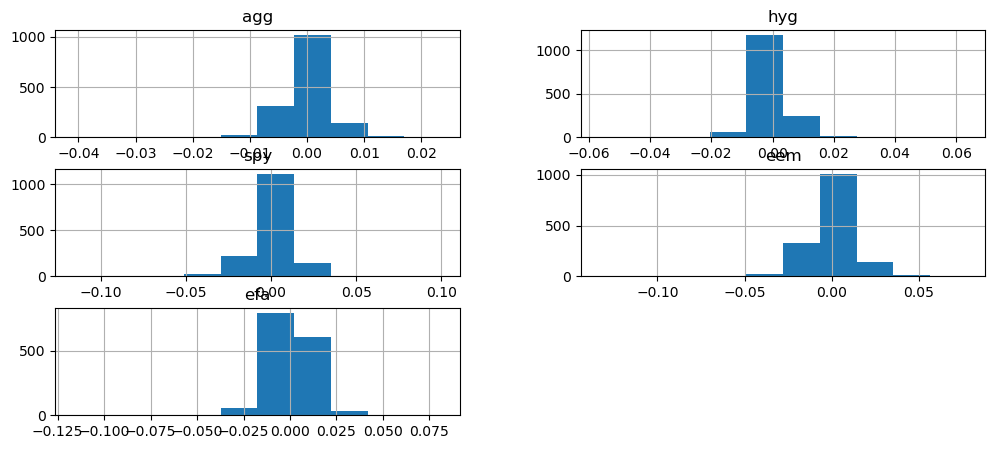

In [10]:
ax = returns.hist(figsize=(12, 5))

In [11]:
returns.corr().as_format('.2f')

,agg,hyg,spy,eem,efa
agg,1.00,0.42,0.18,0.18,0.24
hyg,0.42,1.00,0.79,0.66,0.76
spy,0.18,0.79,1.00,0.76,0.86
eem,0.18,0.66,0.76,1.00,0.84
efa,0.24,0.76,0.86,0.84,1.00


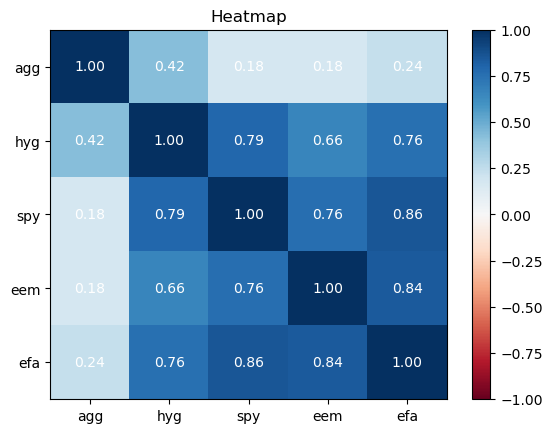

In [12]:
returns.plot_corr_heatmap();

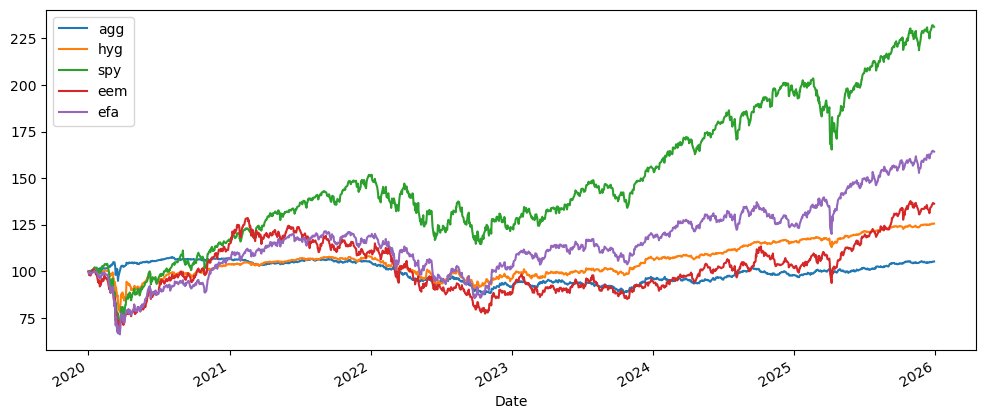

In [13]:
ax = data.rebase().plot(figsize=(12,5))

# Performance Management

In [14]:
perf = data.calc_stats()

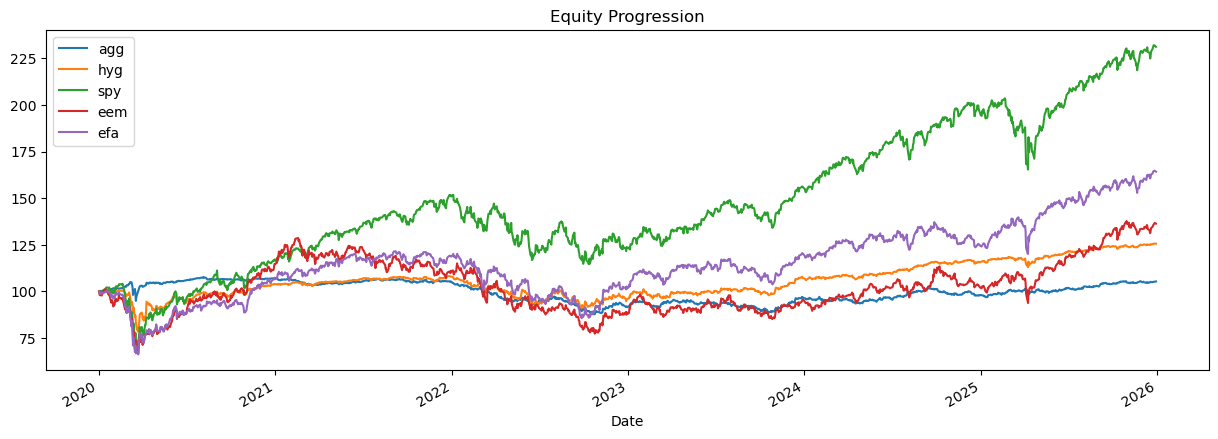

In [15]:
perf.plot();

In [16]:
print(perf.display())

Stat                 agg         hyg         spy         eem         efa
-------------------  ----------  ----------  ----------  ----------  ----------
Start                2020-01-02  2020-01-02  2020-01-02  2020-01-02  2020-01-02
End                  2025-12-29  2025-12-29  2025-12-29  2025-12-29  2025-12-29
Risk-free rate       0.00%       0.00%       0.00%       0.00%       0.00%

Total Return         5.37%       25.65%      131.06%     36.35%      64.20%
Daily Sharpe         0.17        0.44        0.78        0.35        0.53
Daily Sortino        0.26        0.68        1.22        0.55        0.82
CAGR                 0.88%       3.89%       15.00%      5.31%       8.63%
Max Drawdown         -18.43%     -22.03%     -33.72%     -39.82%     -33.93%
Calmar Ratio         0.05        0.18        0.45        0.13        0.25

MTD                  0.00%       0.49%       0.95%       2.07%       2.98%
3m                   1.22%       1.19%       3.95%       4.23%       5.41%
6m        

In [17]:
# we can also use perf[2] in this case
perf['spy'].display_monthly_returns()

  Year    Jan    Feb     Mar    Apr    May    Jun    Jul    Aug    Sep    Oct    Nov    Dec     YTD
------  -----  -----  ------  -----  -----  -----  -----  -----  -----  -----  -----  -----  ------
  2020  -0.97  -7.92  -12.49  12.7    4.76   1.77   5.89   6.98  -3.74  -2.49  10.88   3.7    17.24
  2021  -1.02   2.78    4.54   5.29   0.66   2.24   2.44   2.98  -4.66   7.02  -0.8    4.62   28.73
  2022  -5.27  -2.95    3.76  -8.78   0.23  -8.25   9.21  -4.08  -9.24   8.13   5.56  -5.76  -18.18
  2023   6.29  -2.51    3.71   1.6    0.46   6.48   3.27  -1.63  -4.74  -2.17   9.13   4.57   26.18
  2024   1.59   5.22    3.27  -4.03   5.06   3.53   1.21   2.34   2.1   -0.89   5.96  -2.41   24.89
  2025   2.69  -1.27   -5.57  -0.87   6.28   5.14   2.3    2.05   3.56   2.38   0.19   0.95   18.74


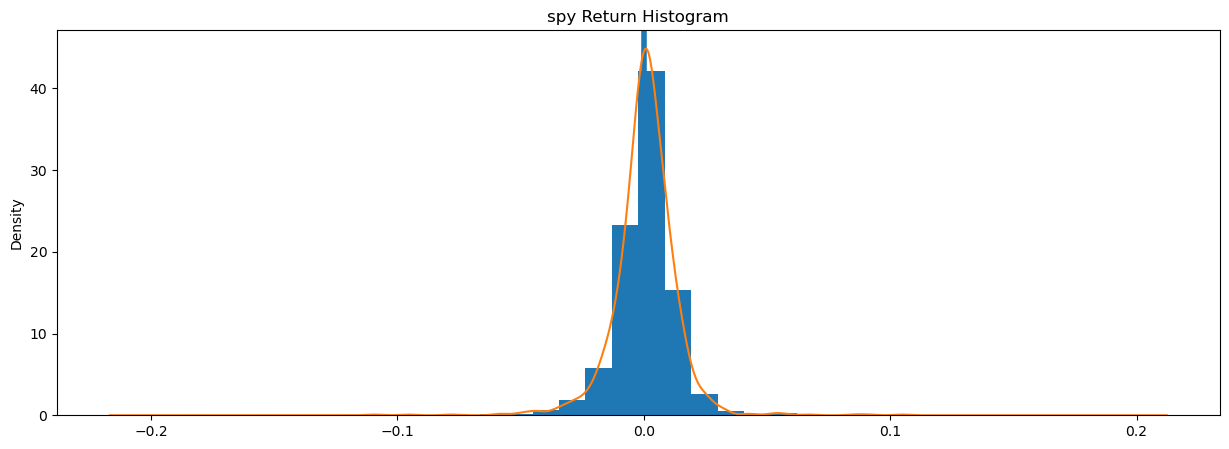

In [18]:
perf[2].plot_histogram();

In [19]:
perf['spy'].stats

start                    2020-01-02 00:00:00
end                      2025-12-29 00:00:00
rf                                       0.0
total_return                        1.310555
cagr                                0.150049
max_drawdown                       -0.337173
calmar                              0.445022
mtd                                   0.0095
three_month                         0.039481
six_month                           0.125035
ytd                                 0.187428
one_year                            0.169606
three_year                          0.231111
five_year                           0.146843
ten_year                                 NaN
incep                               0.150049
daily_sharpe                        0.779737
daily_sortino                       1.218465
daily_mean                          0.161867
daily_vol                           0.207592
daily_skew                         -0.265491
daily_kurt                         13.034182
best_day  

In [20]:
returns.calc_mean_var_weights().as_format('.2%')

agg    15.92%
hyg     0.00%
spy    84.08%
eem     0.00%
efa     0.00%
dtype: object

In [21]:
returns.calc_ftca(threshold=0.8)

{1: ['efa', 'spy', 'eem'], 2: ['agg'], 3: ['hyg']}

## Indian Stocks

In [22]:
data = ffn.get('sbin.ns', start='2020-01-01', end='2025-12-30')
print(data.tail())

[*********************100%***********************]  1 of 1 completed

                sbinns
Date                  
2025-12-23  971.900024
2025-12-24  968.950012
2025-12-25  968.950012
2025-12-26  966.299988
2025-12-29  965.049988


In [23]:
perf = data.calc_stats()

In [24]:
perf.stats

,sbinns
start,2020-01-01 00:00:00
end,2025-12-29 00:00:00
rf,0.0
total_return,2.127161
cagr,0.209537
max_drawdown,-0.555408
calmar,0.377267
mtd,-0.014249
three_month,0.108297
six_month,0.198224
